# Bures--Wasserstein Barycenters of Gaussian Covariances

This notebook generates `fig:barycenters-gaussian-covariances`.  Centered Gaussian Wasserstein barycenters remain Gaussian: only the covariance matrix changes, through the Bures--Wasserstein barycenter equation.  The right grid deliberately uses much stronger anisotropy to make the nonlinear rotation of covariance ellipses visible.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.patches import Ellipse
import ot

NAME = "barycenters-gaussian-covariances"
out = figure_dir(NAME)

In [2]:
def cov(angle, axes):
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s], [s, c]])
    return R @ np.diag(np.asarray(axes) ** 2) @ R.T


def weights(u, v):
    return np.array([(1 - u) * (1 - v), u * (1 - v), (1 - u) * v, u * v])

corner_colors = np.array([
    [0.839, 0.188, 0.153],
    [0.992, 0.682, 0.380],
    [0.482, 0.196, 0.580],
    [0.129, 0.400, 0.675],
])

def color(u, v):
    return tuple(np.clip(weights(u, v) @ corner_colors, 0, 1))


def add_ellipse(ax, mean, Sigma, color, scale=0.72):
    vals, vecs = np.linalg.eigh(Sigma)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    ax.add_patch(Ellipse(mean, width=scale*np.sqrt(vals[0]), height=scale*np.sqrt(vals[1]), angle=angle, facecolor=color, edgecolor="none", lw=0, alpha=0.20))
    ax.add_patch(Ellipse(mean, width=scale*np.sqrt(vals[0]), height=scale*np.sqrt(vals[1]), angle=angle, facecolor="none", edgecolor=color, lw=0.85, alpha=0.92))


def draw_grid(covs, filename):
    uv = np.linspace(0, 1, 5)
    bary = {}
    for v in uv:
        for u in uv:
            bary[(float(u), float(v))] = ot.gaussian.bures_barycenter_fixpoint(covs, weights=weights(float(u), float(v)), num_iter=150, eps=1e-12)
    maxstd = max(np.sqrt(np.linalg.eigvalsh(S).max()) for S in bary.values())
    fig, ax = plt.subplots(figsize=(2.9, 2.9))
    for row, v in enumerate(uv[::-1]):
        for col, u in enumerate(uv):
            S = bary[(float(u), float(v))]
            add_ellipse(ax, np.array([col + 0.5, row + 0.5]), S / (maxstd ** 2), color(float(u), float(v)))
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.030)
    plt.close(fig)

moderate = np.array([
    cov(-0.65, (0.90, 0.28)),
    cov(0.36, (0.40, 0.96)),
    cov(1.10, (0.78, 0.25)),
    cov(-0.12, (0.58, 0.48)),
])
anisotropic = np.array([
    cov(-0.95, (1.42, 0.065)),
    cov(0.78, (0.075, 1.38)),
    cov(1.42, (1.26, 0.075)),
    cov(-0.36, (1.18, 0.085)),
])
draw_grid(moderate, "moderate-grid.pdf")
draw_grid(anisotropic, "anisotropic-grid.pdf")


Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.
Dit not converge.


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


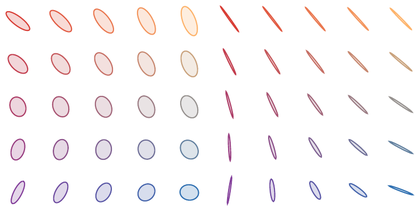

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/barycenters-gaussian-covariances.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/barycenters-gaussian-covariances.png")
display(Image(filename=str(_thumb)))
